# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating FIREBENCH Benchmarks 

Here we will evaluate the raw query metrics returned by Firebench. These raw metrics were calculated using [Firebench](https://huggingface.co/datasets/sagecontinuum/FireBench) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), [NRP's](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) [gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it), and set to **response_limit=25**. This means it will return up to 25 images. This was configured this way to match production deployment.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version is **query-only** on the v15 collections (`SKIP_INDEX=true`, **no recaption**). It tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25, CLIP rerank, and Image Byte limiting. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.65 → 65% dense / 35% keyword; effective WeightedRanker **46% image / 20% caption / 35% BM25**). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.
- **LLM Image Byte Limiting**: Caption images are preprocessed with `LLM_IMAGE_BYTE_LIMITING=true` before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
- **Two-caption prompt (`scientific_two_captions_v1`)**: Caption generation uses the shared [`prompts/`](../../../../../prompts/) catalog (`CAPTION_PROMPT_ID=scientific_two_captions_v1`). Gemma returns three fields: `long_caption` (full detail), `short_caption` (one dense visual sentence, ≤55 tokens, no device IDs/timestamps), and 15 `keywords`. The older versions used CAPTION_PROMPT_ID=scientific_detailed_v1 which utilized only long_caption.
- **CLIP text vs BM25 text split**: CLIP's 77-token limit previously truncated the full caption+keywords string (~40% embedded; keywords never reached `caption_vector`). v15 embeds **`short_caption` + `keywords`** for `caption_vector` in a single CLIP pass, while BM25 `search_text` still indexes **`long_caption` + keywords** (no detail lost on the keyword leg).
- **Milvus caption fields**: `long_caption` and `short_caption` are stored as separate VARCHAR fields (replacing a single `caption` column).
- **Query-only (`SKIP_INDEX=true`)**: Reuses the **v15 Milvus collections**. No recaption and no collection drop. v16 only changes hybrid blend weights at query time. The A–H skip-index sweep is archived in `results/v16/v16_qa*`; this notebook plots production pick **H**.

Here were the Hyperparameters used for the image search:


In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'query_alpha': 0.65, 'clip_alpha': 0.7, 'enab...",dict
1,caption_model_name,gemma,str
2,caption_model_prompt,role:\nYou are a world-class Scientific Image ...,str
3,embed_caption,True,bool
4,embed_image,True,bool
5,enable_bm25,True,bool
6,enable_caption_generation,True,bool
7,firebench_dataset,sagecontinuum/FireBench,str
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and Image Collection Process

This explanation was grabbed from the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) in huggingface so that we can better understand the results in further sections.

### Query Collection

Queries in FireBench are **natural-language descriptions of wildfire phenomena**, written to reflect how fire scientists would search for imagery. They are not manually authored by humans; instead they are **generated by an AI text model (OpenAI, GPT-5-mini) from seed images**.

**Process:**

1. **Seed images** — A fixed number of seed images (controlled by the `FIREBENCH_NUM_SEEDS` hyperparameter) are selected from the candidate image pool.
2. **Query generation** — For each seed, the text API is given the image (and any associated context) and is prompted to produce a natural-language query that a fire scientist might use to find that kind of scene. The model is instructed to adopt a fire-scientist perspective so the queries reflect realistic search intents (e.g., "Fixed long-range daytime webcam images of mountainous shrubland with no visible smoke or flames").
3. **One query per seed** — Each generated query is assigned a unique `query_id` (e.g. `firebench_q001`, `firebench_q002`) and is then used to retrieve and label candidate images.

The result is a set of **expert-style queries** over wildfire imagery that support evaluation of text-to-image retrieval, relevance classification, and robustness to confounders (e.g., fog, haze, clouds). For full pipeline details and hyperparameters, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) and the `config_values.csv` in the benchmark's `summary/` directory.


### Image Annotation

FireBench annotates images in two main ways: **vision-based description** of each image, and **relevance labeling** for each query–image pair. Both are automated with AI models (OpenAI APIs), not human annotators.

**1. Vision annotation (per image)**  
Each image is processed with **OpenAI’s vision API (GPT-5-mini)** to produce:

- **Summary** — A short factual description (≤30 words).
- **Categorical facets** — From fixed taxonomies: `viewpoint` (e.g. fixed_long_range, handheld, aerial), `plume_stage` (e.g. none, developing, mature), `lighting` (e.g. day, night, ir_nir), `confounder_type` (e.g. none, haze, cloud, sun_glare), and `environment_type` (e.g. mountainous, forest, shrubland).
- **Controlled vocabulary tags** — Typically 12–18 tags per image (e.g. no_smoke_visible, daylight, sky_dominant, foreground_terrain).
- **Confidence scores** — For each categorical facet, a score between 0 and 1.

**2. Relevance labeling (per query–image pair)**  
For each query, candidate images are scored as **relevant (1)** or **not relevant (0)** by an **AI judge** using OpenAI’s text API (GPT-5-mini), prompted to reflect fire-scientist criteria. This yields the binary `relevance_label` used for retrieval metrics.

**3. CLIPScore (per query–image pair)**  
A **CLIP similarity score** between the query text and the image is computed offline using the model `apple/DFN5B-CLIP-ViT-H-14-378` and stored in the dataset as `clip_score`.

For annotation prompts and hyperparameters (e.g. `VISION_ANNOTATION_*`, `JUDGE_*`), see the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) and the benchmark’s `summary/config_values.csv`.


### Query Categories

FireBench does not assign each query to a single category. Instead, **queries are characterized by the same metadata dimensions used for images**, so that retrieval can be analyzed (and evaluated) along fire-science-relevant axes. Each query–image pair has metadata from these **locked taxonomies** (defined in the dataset creation config):

- **viewpoint** — How the scene was captured (e.g. `fixed_long_range`, `handheld`, `aerial`).
- **plume_stage** — Smoke-plume stage when relevant (e.g. `none`, `incipient`, `developing`, `mature`).
- **lighting** — Conditions (e.g. `day`, `dusk`, `night`, `ir_nir`).
- **confounder_type** — Confounders that can cause false positives (e.g. `none`, `haze`, `cloud`, `fog_marine_layer`, `sun_glare`).
- **environment_type** — Setting (e.g. `mountainous`, `forest`, `shrubland`).
- **flame_visible** — Whether flames are visible in the image (boolean).

Queries therefore span **clear/baseline conditions** (no smoke or flames), **smoke and plume conditions** (various stages), and **confounder-heavy conditions** (haze, clouds, etc.), so the benchmark can measure both recall of relevant fire imagery and robustness against false positives. For the exact taxonomy values, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/FireBench) and the benchmark’s `summary/config_values.csv` (e.g. `VIEWPOINT`, `PLUME_STAGE`, `LIGHTING`, `CONFOUNDER`, `ENVIRONMENT`).

### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/FireBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/FireBench/resolve/main/summary/image_proportion_donuts.png)

## Exploratory Data Analysis

The dataset provides an EDA of the data. If you are interested in finding out more analytical information about the data, please refer to it.

[Firebench EDA](https://huggingface.co/datasets/sagecontinuum/FireBench/blob/main/summary/firebench_eda_analysis.ipynb)
>NOTE: The EDA can be used along side these evaluation metrics to better understand the results.

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries created by the INQUIRE authors.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: 1 if atleast one relevant image was returned. Take the average of this metric to get the hit rate which is the percentage of queries that had at least one relevant image returned in the top k images (k = response limit).
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rr**: The reciprocal rank of the rerank scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column clip_rr.
- **clip_rr**: The reciprocal rank of the clip scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column rr. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If rr is higher than this column, that means our image search system is doing better.
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **environment_type**: The environment type of the original image the query was generated from.
- **confounder_type**: The confounder type of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **flame_visible**: Whether the original image the query was generated from has a flame visible.
- **plume_stage**: The plume stage of the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.


In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,NDCG,clip_NDCG,rr,clip_rr,environment_type,confounder_type,lighting,flame_visible,plume_stage,viewpoint
0,firebench_q007,Daytime fixed webcam view showing a distant sm...,25,0,25,0,25,0.00,0.00,0.000000,...,0.778322,0.977568,1.000000,1.0,mountainous,cloud,day,False,incipient,fixed_long_range
1,firebench_q005,Daytime fixed long-range camera views of dry s...,25,1,24,1,24,0.04,0.04,0.027778,...,0.936051,0.953281,1.000000,1.0,mountainous,none,day,False,none,fixed_long_range
2,firebench_q006,Daytime fixed long‑range webcam views of mount...,25,2,23,2,23,0.08,0.08,0.055556,...,0.882032,0.995603,1.000000,1.0,shrubland,none,day,False,none,fixed_long_range
3,firebench_q003,Daytime fixed-mount long-range mountain webcam...,25,2,23,2,23,0.08,0.08,0.057143,...,0.752632,0.939543,0.500000,1.0,mountainous,none,day,False,none,fixed_long_range
4,firebench_q001,Fixed long-range daytime webcam images of moun...,25,1,24,1,24,0.04,0.04,0.027778,...,0.851286,0.941539,1.000000,1.0,mountainous,none,day,False,none,fixed_long_range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,firebench_q098,Daytime fixed long-range webcam images of moun...,25,0,25,0,25,0.00,0.00,0.000000,...,0.580548,0.805223,0.250000,1.0,mountainous,haze,day,False,none,fixed_long_range
96,firebench_q094,Aerial views of coniferous forest with low-lyi...,25,4,21,3,22,0.16,0.12,0.200000,...,0.836537,0.967752,1.000000,1.0,forest,fog_marine_layer,day,False,none,aerial
97,firebench_q096,Dusk long-range mountain/webcam images showing...,25,2,23,2,23,0.08,0.08,0.076923,...,0.612694,0.879770,0.250000,1.0,mountainous,cloud,dusk,False,none,fixed_long_range
98,firebench_q099,Dusk/dawn long-range mountain-valley webcam ph...,25,3,22,3,22,0.12,0.12,0.230769,...,0.756901,0.981937,0.500000,1.0,mountainous,fog_marine_layer,dusk,False,none,fixed_long_range


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [4]:
render_dlq_analysis(Path("."))


DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


We can see here that Byte limiting helped, no errors were returned. Although, implementing Byte limiting causes images to be downsized so retrieval performance can decrease so lets see the metrics.

## Overall Metrics
Now, we will begin with evaluating all queries.

In [5]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 2500
correctly_returned: 178
incorrectly_returned: 2322
relevant_images: 142
non_relevant_images: 2358
accuracy: 0.07120000000000001
precision: 0.056799999999999996
recall: 0.10131641781848394
hit_rate: 0.62
NDCG: 0.8016926683263086
clip_NDCG: 0.9217023953753214
mrr: 0.7258333333333333
clip_mrr: 0.9491666666666666
diversity: 0.2806886706537497

Insights:
The system returned a total of 178 correct images out of 2500 total images returned.
The accuracy of the system is 0.0712, indicating that 7.12% of the returned images correctly matched with the query.
The precision of the system is 0.0568, indicating that 5.68% of the total images returned were relevant images.
The recall of the system is 0.1013, indicating that 10.13% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.6200, indicating that 62.00% of the total queries processed had at least one relevant image.
The NDCG score is 0.8017, and the Clip NDCG score is 0.9217, indicating 

## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [6]:
# Group by environment type and calculate the sum/mean of each metric
environment_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
environment_metrics = environment_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

environment_metrics

,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,coastal,50,8,42,4,46,0.160000,0.080000,0.583333,1.000000,0.877907,0.915241,1.000000,1.000000,0.323946
1,forest,1000,79,921,61,939,0.079000,0.061000,0.100980,0.650000,0.812475,0.901511,0.766250,0.914583,0.259039
2,grassland,200,10,190,6,194,0.050000,0.030000,0.045089,0.375000,0.791087,0.906283,0.837500,0.854167,0.263539
3,mountainous,950,68,882,59,891,0.071579,0.062105,0.103730,0.605263,0.782991,0.938072,0.644737,0.986842,0.320482
4,other,25,1,24,1,24,0.040000,0.040000,0.035714,1.000000,0.954332,0.992157,1.000000,1.000000,0.290056
5,shrubland,200,8,192,7,193,0.040000,0.035000,0.058798,0.625000,0.845623,0.947387,0.875000,1.000000,0.269718
6,unknown,75,4,71,4,71,0.053333,0.053333,0.039075,0.666667,0.704262,0.937028,0.244444,1.000000,0.108325


### Accuracy

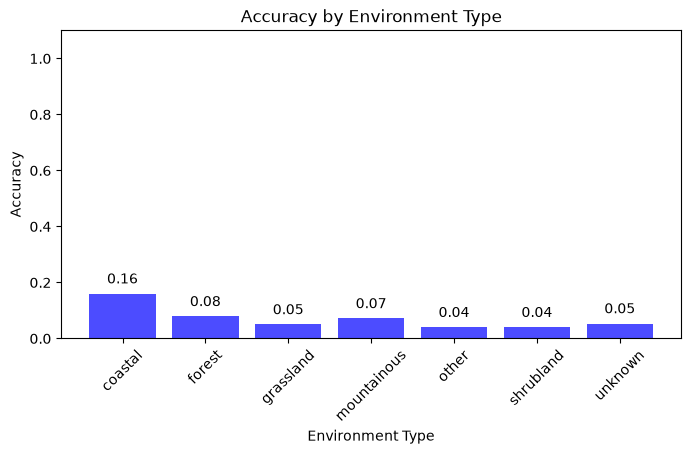

In [7]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='accuracy', title='Accuracy by Environment Type', ylabel='Accuracy', xlabel='Environment Type')

### Precision

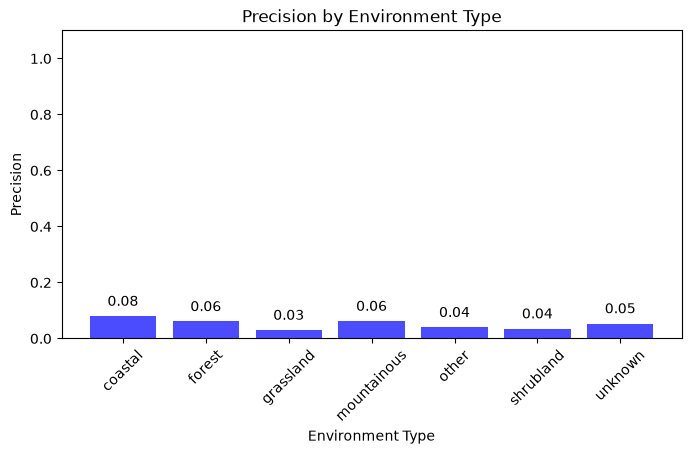

In [8]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='precision', title='Precision by Environment Type', ylabel='Precision', xlabel='Environment Type')

### Recall

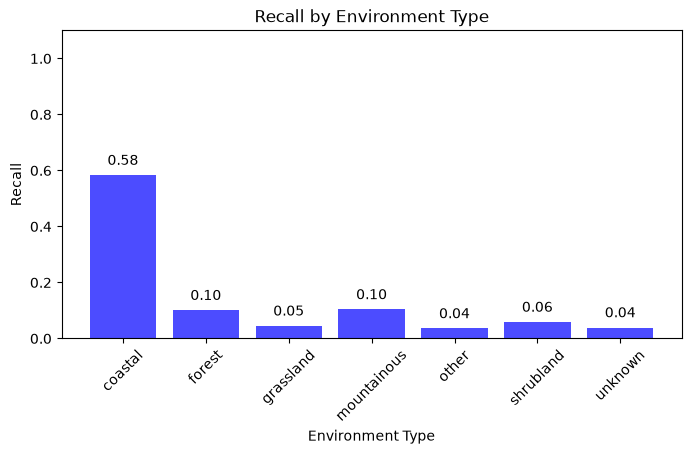

In [9]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='recall', title='Recall by Environment Type', ylabel='Recall', xlabel='Environment Type')

### Hit Rate

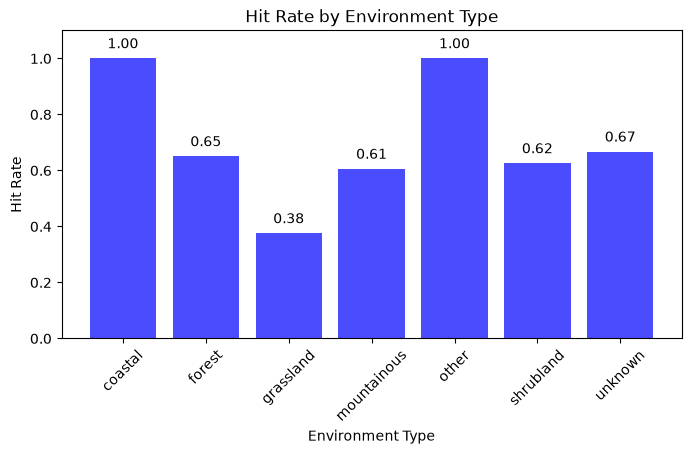

In [10]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='hit_rate', title='Hit Rate by Environment Type', ylabel='Hit Rate', xlabel='Environment Type')

### Diversity


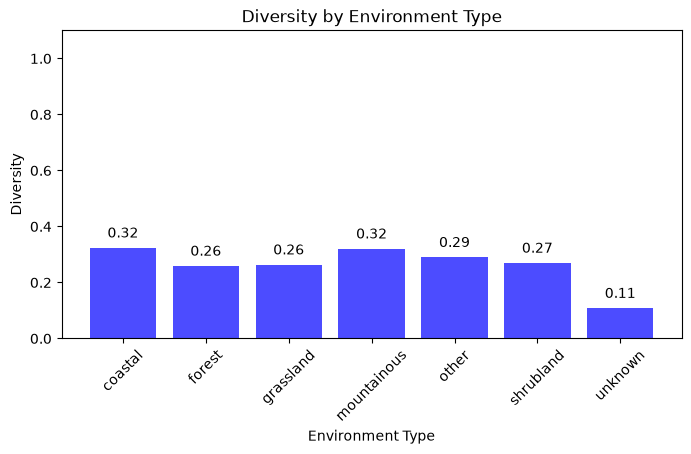

In [11]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='diversity', title='Diversity by Environment Type', ylabel='Diversity', xlabel='Environment Type')

### NDCG

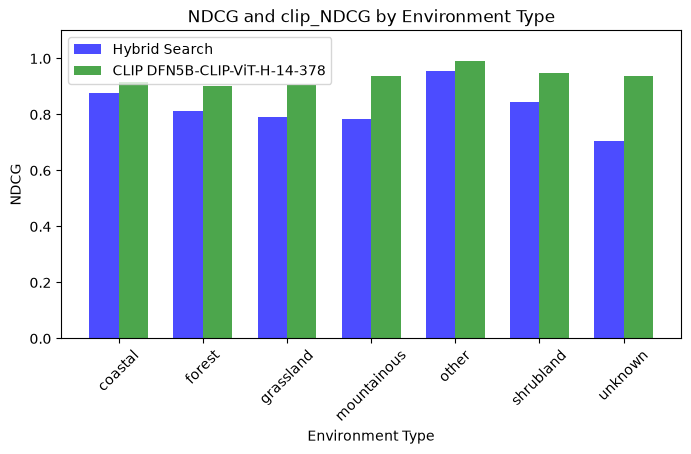

In [12]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='NDCG and clip_NDCG by Environment Type', xlabel='Environment Type')

### MRR

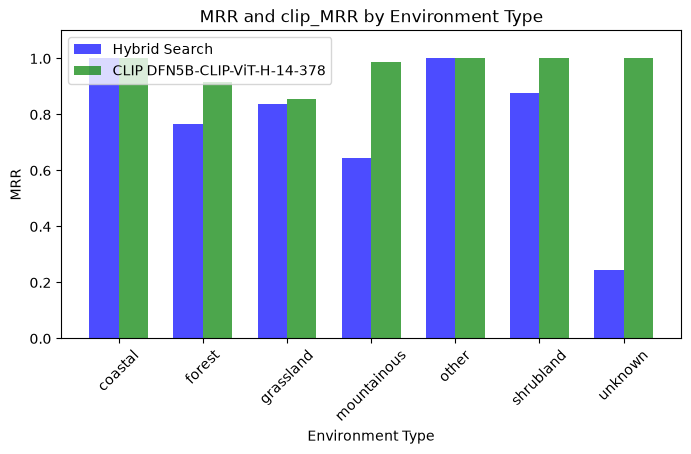

In [13]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='MRR and clip_MRR by Environment Type', xlabel='Environment Type', metric="MRR")

## Metrics based on Confounder Type

In [14]:
# Group by confounder type and calculate the sum/mean of each metric
confounder_metrics = df.groupby('confounder_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
confounder_metrics = confounder_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

confounder_metrics

,confounder_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,cloud,600,37,563,34,566,0.061667,0.056667,0.078774,0.500000,0.822424,0.913480,0.746528,0.906250,0.255204
1,fog_marine_layer,475,39,436,33,442,0.082105,0.069474,0.092054,0.789474,0.865868,0.929955,0.855263,0.973684,0.298620
2,haze,250,15,235,11,239,0.060000,0.044000,0.141734,0.500000,0.773244,0.940061,0.745000,1.000000,0.296813
3,none,950,65,885,47,903,0.068421,0.049474,0.098269,0.605263,0.767682,0.915853,0.674123,0.938596,0.278260
4,sun_glare,175,19,156,14,161,0.108571,0.080000,0.178509,0.857143,0.813360,0.924435,0.707143,1.000000,0.355943
5,unknown,50,3,47,3,47,0.060000,0.060000,0.045455,0.500000,0.690865,0.951756,0.200000,1.000000,0.118286


### Accuracy

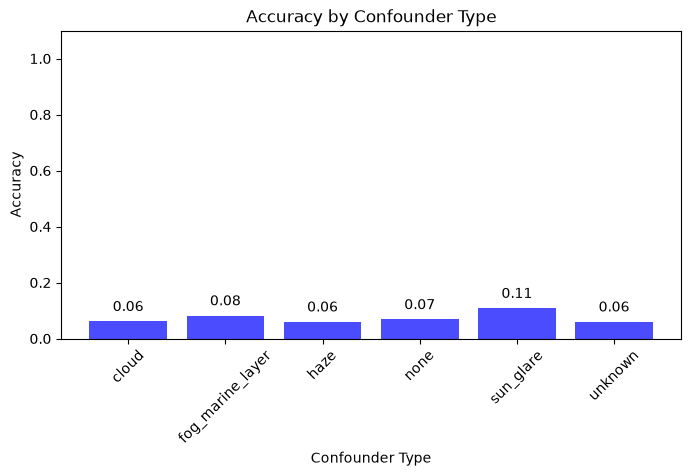

In [15]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='accuracy', title='Accuracy by Confounder Type', ylabel='Accuracy', xlabel='Confounder Type')

### Precision

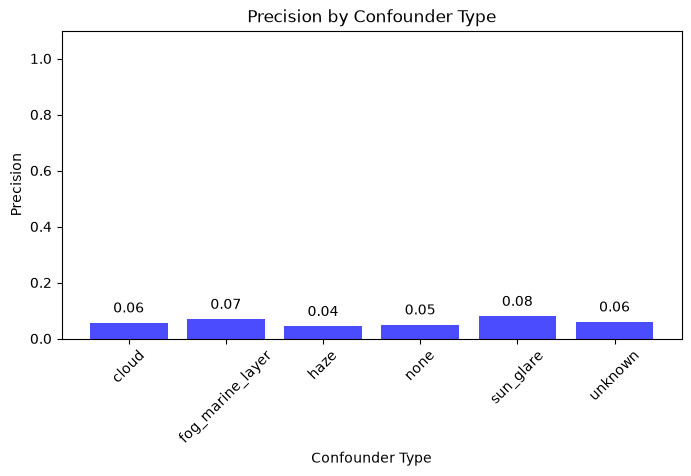

In [16]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='precision', title='Precision by Confounder Type', ylabel='Precision', xlabel='Confounder Type')

### Recall

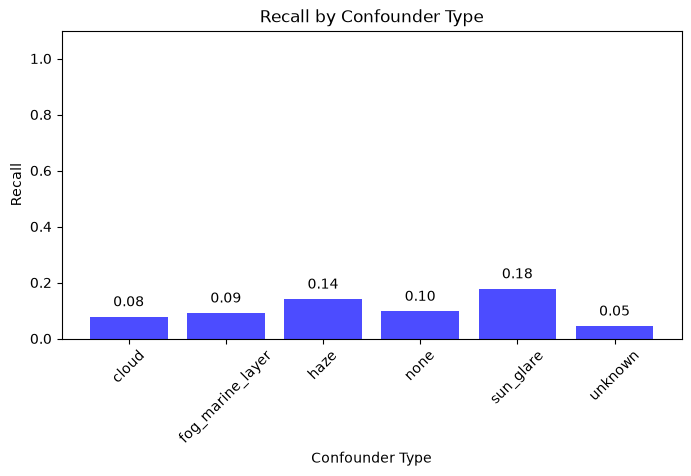

In [17]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='recall', title='Recall by Confounder Type', ylabel='Recall', xlabel='Confounder Type')

### Hit Rate

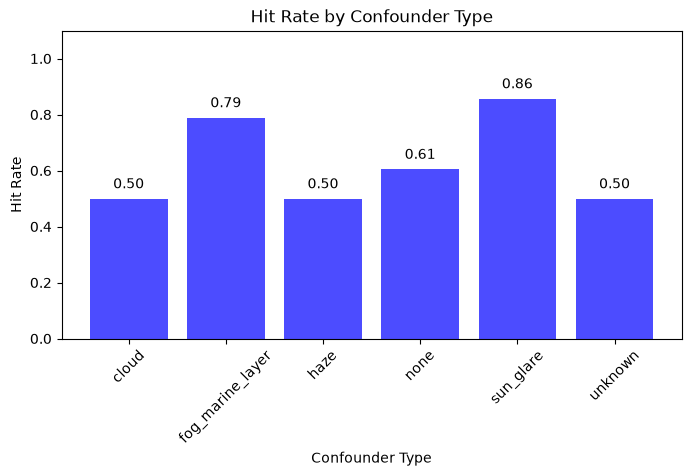

In [18]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='hit_rate', title='Hit Rate by Confounder Type', ylabel='Hit Rate', xlabel='Confounder Type')

### Diversity


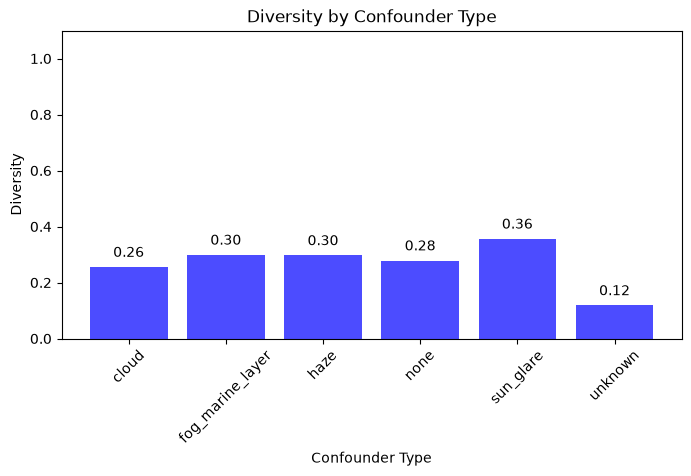

In [19]:
plot_single_bar_metric(confounder_metrics, x_column='confounder_type', metric='diversity', title='Diversity by Confounder Type', ylabel='Diversity', xlabel='Confounder Type')

### NDCG

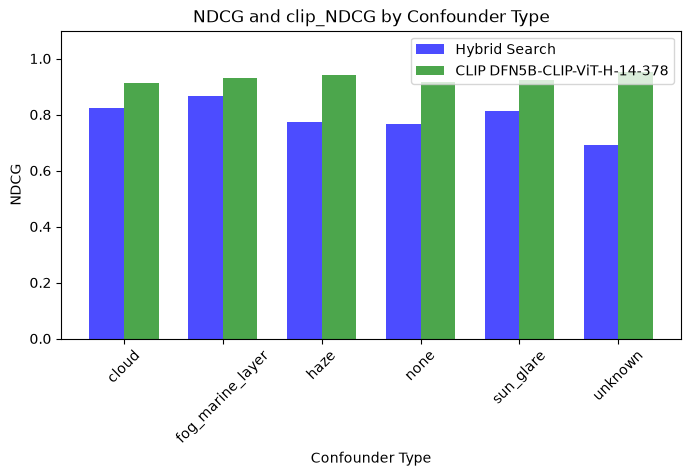

In [20]:
plot_rank_comparison(confounder_metrics, x_column='confounder_type', title='NDCG and clip_NDCG by Confounder Type', xlabel='Confounder Type')

### MRR

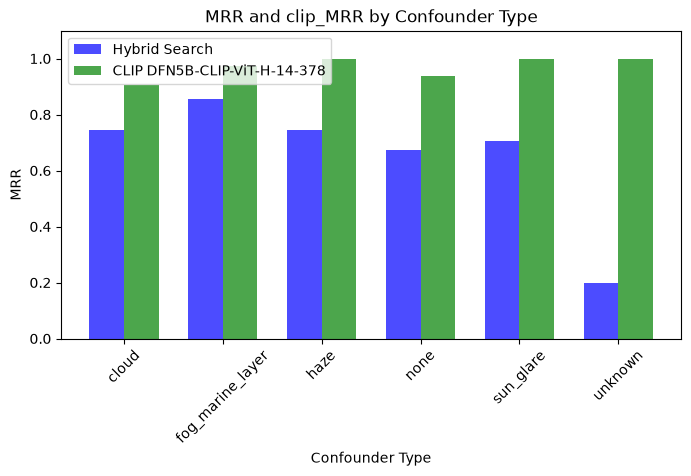

In [21]:
plot_rank_comparison(confounder_metrics, x_column='confounder_type', title='MRR and clip_MRR by Confounder Type', xlabel='Confounder Type', metric="MRR")

## Metrics based on Lighting

In [22]:


# Group by iconic_group and calculate the sum/mean of each metric
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,day,1975,128,1847,99,1876,0.064810,0.050127,0.091010,0.569620,0.810815,0.923222,0.760970,0.958861,0.279776
1,dusk,200,24,176,19,181,0.120000,0.095000,0.213908,1.000000,0.751879,0.895352,0.587500,0.937500,0.381907
2,ir_nir,75,2,73,1,74,0.026667,0.013333,0.008772,0.333333,0.787621,0.901211,0.511111,0.777778,0.146699
3,night,250,24,226,23,227,0.096000,0.092000,0.120431,0.800000,0.773698,0.936925,0.623333,0.933333,0.247122


In [23]:
# Bar width
bar_width = 0.35
x = np.arange(len(lighting_metrics['lighting']))

### Accuracy

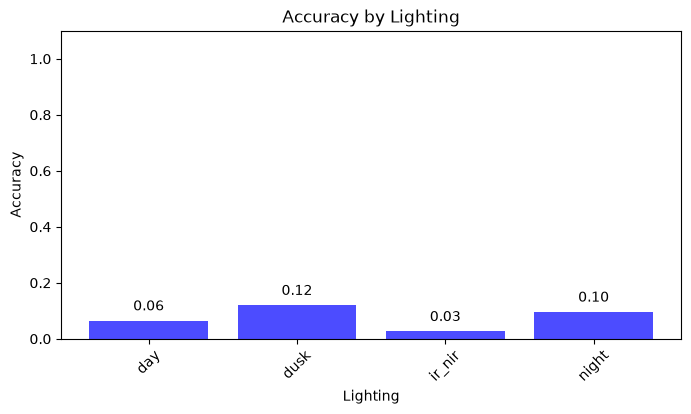

In [24]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='accuracy', title='Accuracy by Lighting', ylabel='Accuracy', xlabel='Lighting')

### Precision

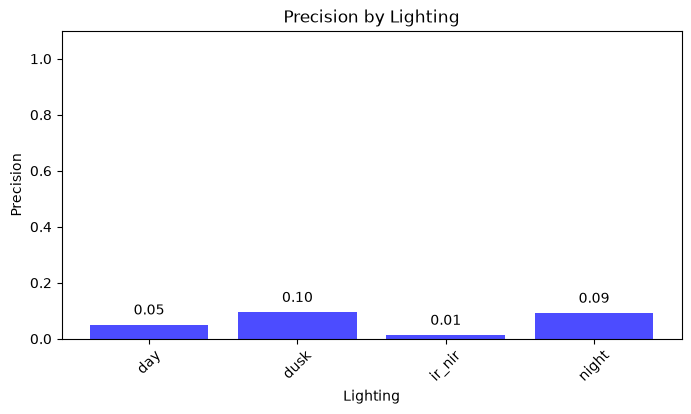

In [25]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='precision', title='Precision by Lighting', ylabel='Precision', xlabel='Lighting')

### Recall

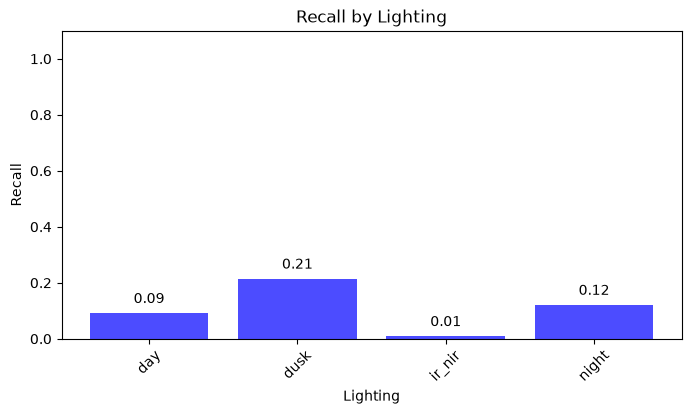

In [26]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='recall', title='Recall by Lighting', ylabel='Recall', xlabel='Lighting')

### Hit Rate

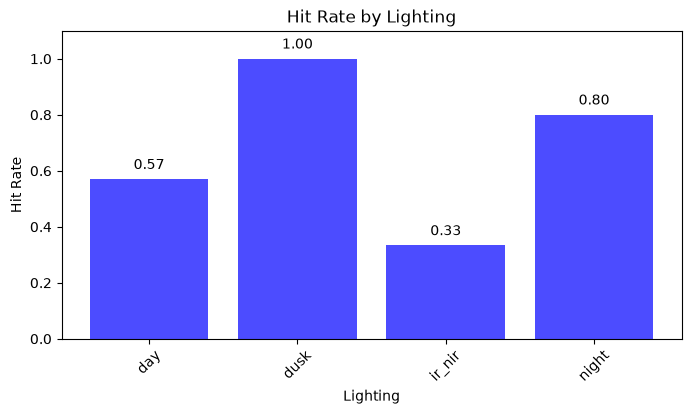

In [27]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='hit_rate', title='Hit Rate by Lighting', ylabel='Hit Rate', xlabel='Lighting')

### Diversity

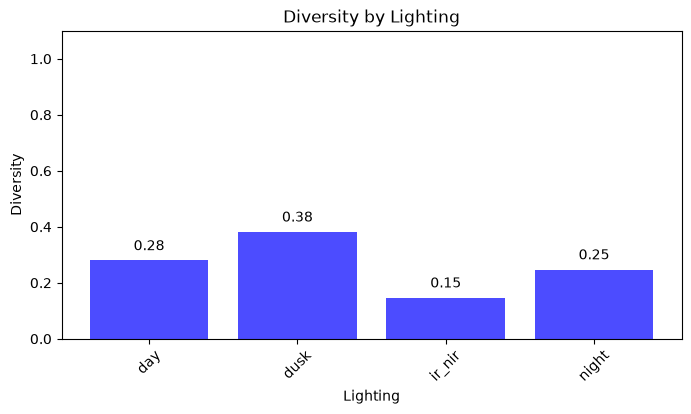

In [28]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='diversity', title='Diversity by Lighting', ylabel='Diversity', xlabel='Lighting')

### NDCG

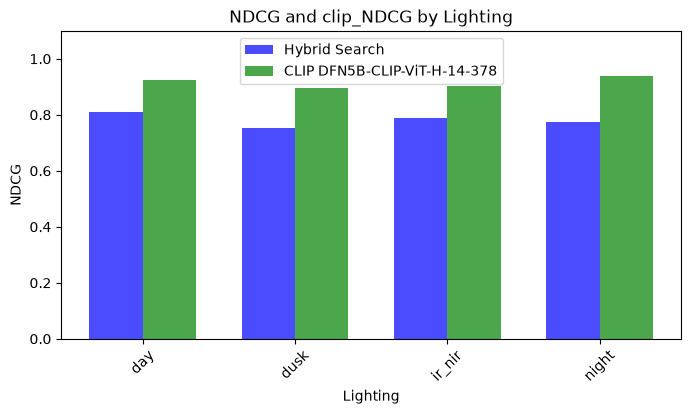

In [29]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='NDCG and clip_NDCG by Lighting', xlabel='Lighting')

### MRR

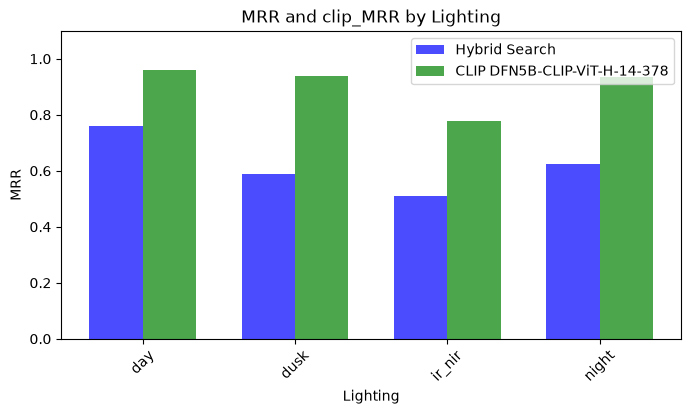

In [30]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='MRR and clip_MRR by Lighting', xlabel='Lighting', metric="MRR")

## Metrics based on Flame Visible

In [31]:
# Group by flame visible and calculate the sum/mean of each metric
flame_visible_metrics = df.groupby('flame_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
flame_visible_metrics = flame_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# use true and false instead of 1 and 0
flame_visible_metrics['flame_visible'] = flame_visible_metrics['flame_visible'].map({True: 'True', False: 'False'})
flame_visible_metrics

,flame_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2350,163,2187,133,2217,0.069362,0.056596,0.098131,0.606383,0.808288,0.921407,0.720745,0.945922,0.283829
1,True,150,15,135,9,141,0.100000,0.060000,0.151226,0.833333,0.698367,0.926331,0.805556,1.000000,0.231484


### Accuracy

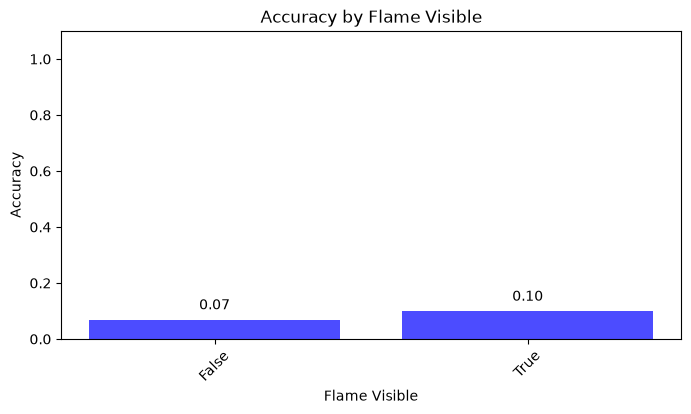

In [32]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='accuracy', title='Accuracy by Flame Visible', ylabel='Accuracy', xlabel='Flame Visible')

### Precision

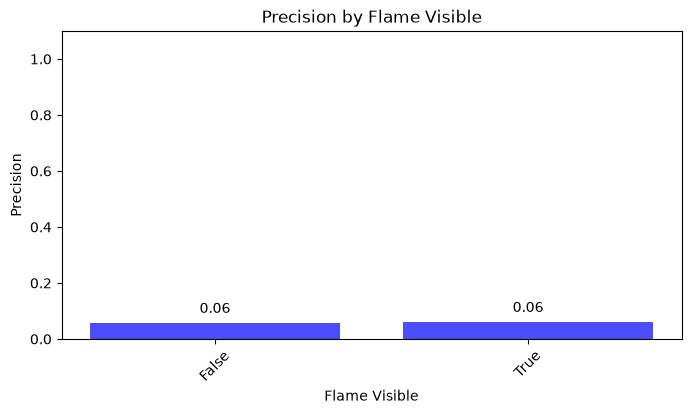

In [33]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='precision', title='Precision by Flame Visible', ylabel='Precision', xlabel='Flame Visible')

### Recall

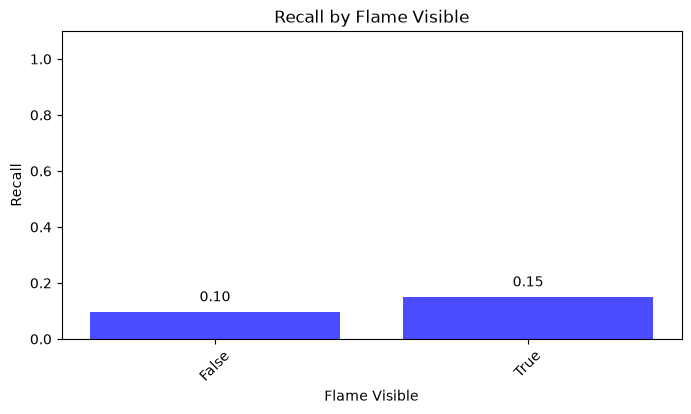

In [34]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='recall', title='Recall by Flame Visible', ylabel='Recall', xlabel='Flame Visible')

### Hit Rate

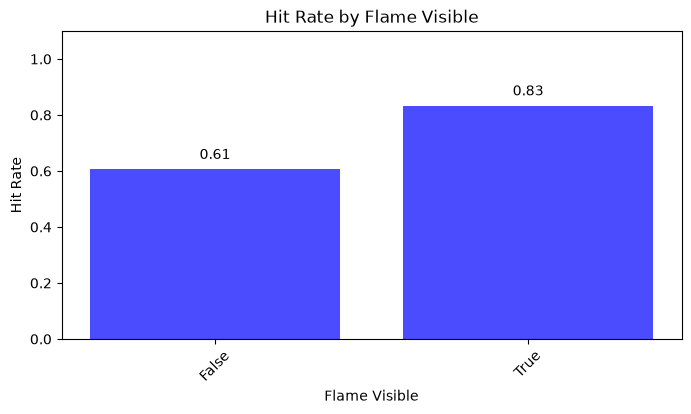

In [35]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='hit_rate', title='Hit Rate by Flame Visible', ylabel='Hit Rate', xlabel='Flame Visible')

### Diversity


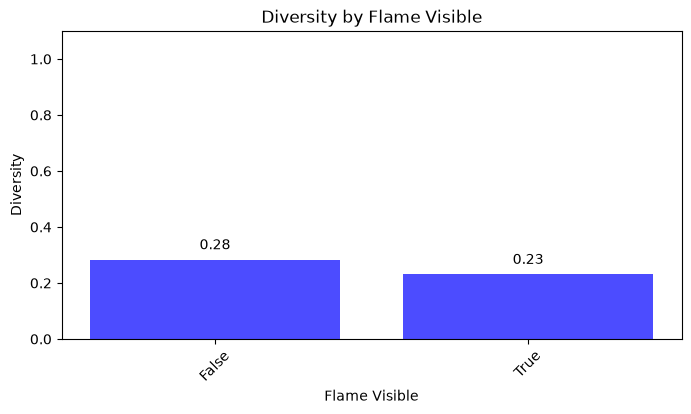

In [36]:
plot_single_bar_metric(flame_visible_metrics, x_column='flame_visible', metric='diversity', title='Diversity by Flame Visible', ylabel='Diversity', xlabel='Flame Visible')

### NDCG

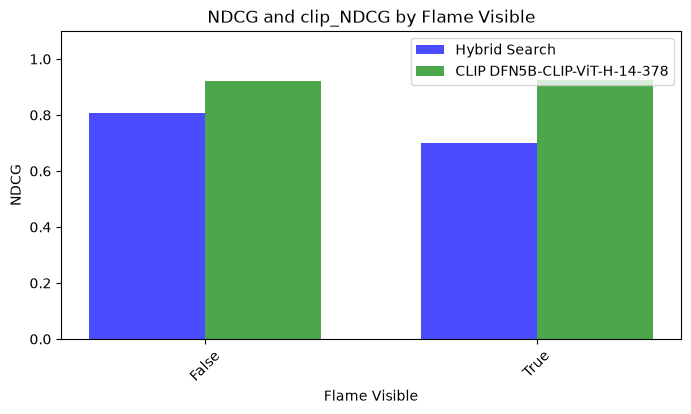

In [37]:
plot_rank_comparison(flame_visible_metrics, x_column='flame_visible', title='NDCG and clip_NDCG by Flame Visible', xlabel='Flame Visible')

### MRR

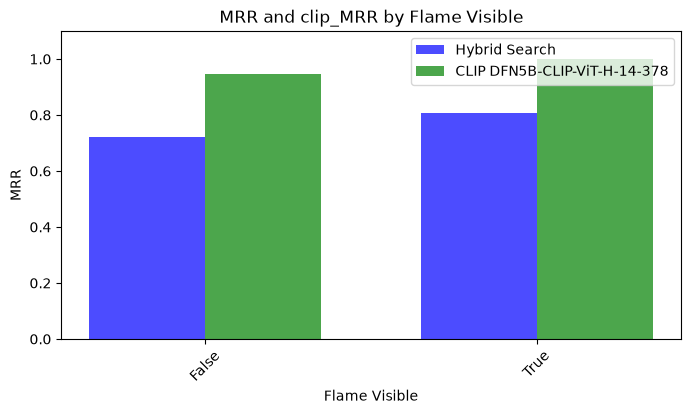

In [38]:
plot_rank_comparison(flame_visible_metrics, x_column='flame_visible', title='MRR and clip_MRR by Flame Visible', xlabel='Flame Visible', metric="MRR")

## Metrics based on Plume Stage

In [39]:
# Group by plume stage and calculate the sum/mean of each metric
plume_stage_metrics = df.groupby('plume_stage').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
plume_stage_metrics = plume_stage_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

plume_stage_metrics

,plume_stage,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,developing,600,46,554,34,566,0.076667,0.056667,0.088672,0.583333,0.840919,0.899872,0.820833,0.878472,0.257220
1,incipient,100,2,98,2,98,0.020000,0.020000,0.050000,0.250000,0.681909,0.844656,0.550000,0.833333,0.279132
2,mature,400,29,371,21,379,0.072500,0.052500,0.119824,0.687500,0.743252,0.904519,0.760417,0.937500,0.216462
3,none,1325,90,1235,78,1247,0.067925,0.058868,0.100583,0.622642,0.813066,0.948757,0.684277,1.000000,0.306874
4,residual,50,9,41,5,45,0.180000,0.100000,0.134848,1.000000,0.693789,0.767638,0.625000,0.750000,0.318022
5,unknown,25,2,23,2,23,0.080000,0.080000,0.285714,1.000000,0.887475,0.902961,1.000000,1.000000,0.415316


### Accuracy

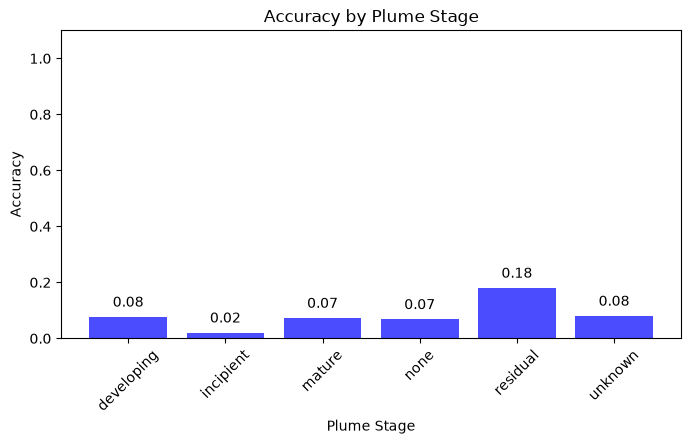

In [40]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='accuracy', title='Accuracy by Plume Stage', ylabel='Accuracy', xlabel='Plume Stage')

### Precision

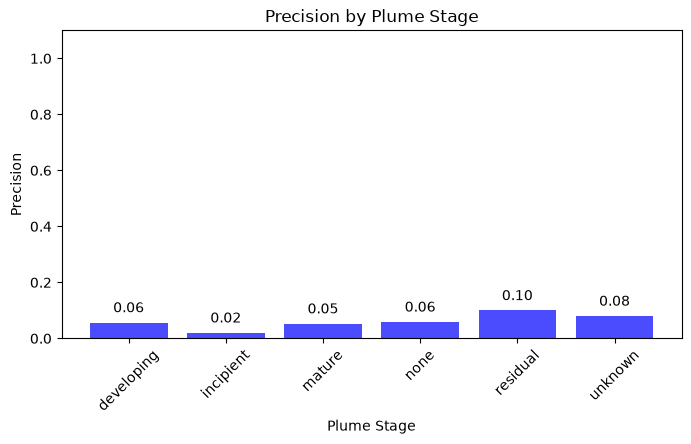

In [41]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='precision', title='Precision by Plume Stage', ylabel='Precision', xlabel='Plume Stage')

### Recall

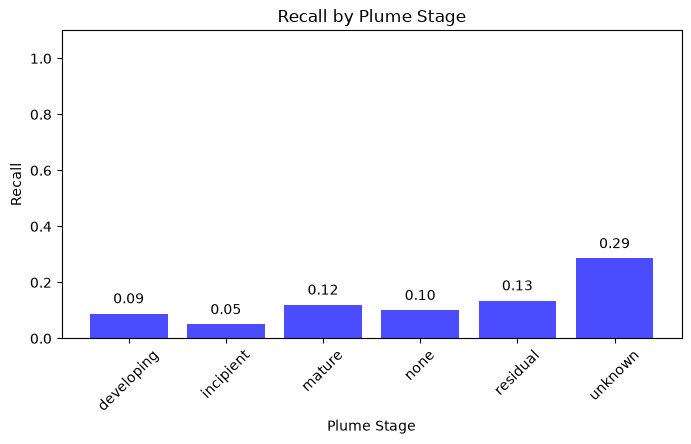

In [42]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='recall', title='Recall by Plume Stage', ylabel='Recall', xlabel='Plume Stage')

### Hit Rate

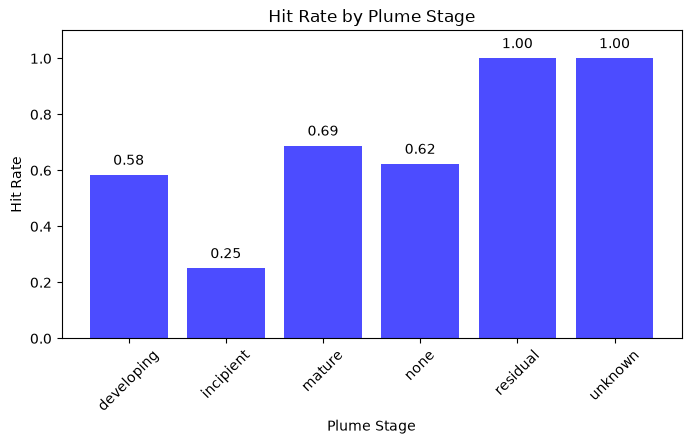

In [43]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='hit_rate', title='Hit Rate by Plume Stage', ylabel='Hit Rate', xlabel='Plume Stage')

### Diversity

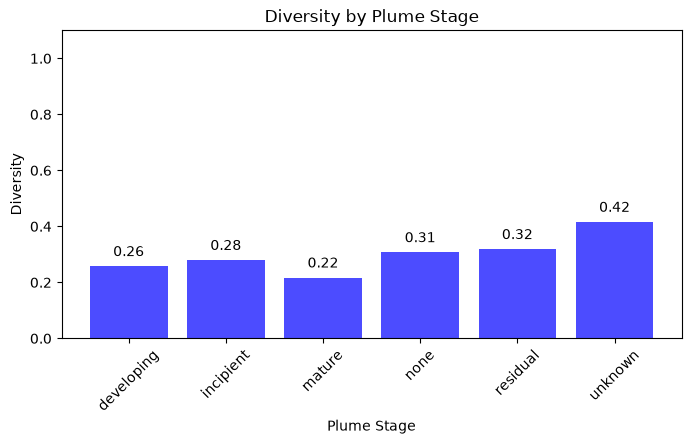

In [44]:
plot_single_bar_metric(plume_stage_metrics, x_column='plume_stage', metric='diversity', title='Diversity by Plume Stage', ylabel='Diversity', xlabel='Plume Stage')

### NDCG

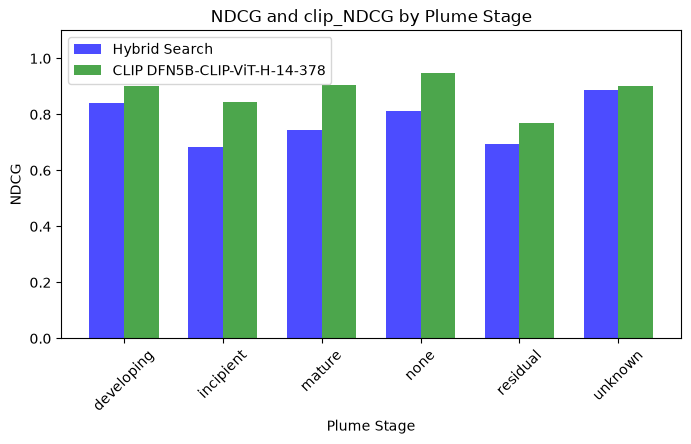

In [45]:
plot_rank_comparison(plume_stage_metrics, x_column='plume_stage', title='NDCG and clip_NDCG by Plume Stage', xlabel='Plume Stage')

### MRR

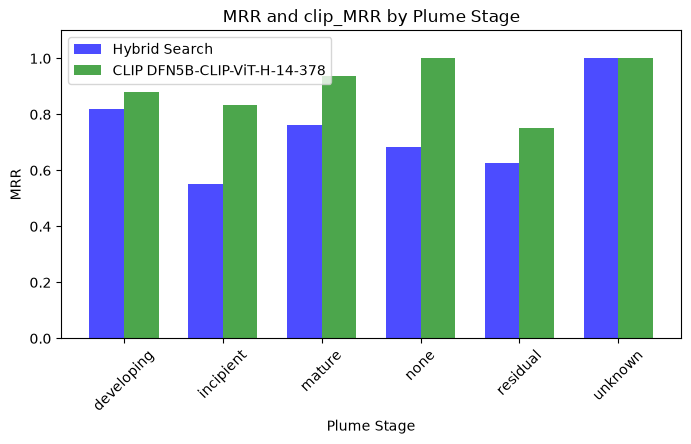

In [46]:
plot_rank_comparison(plume_stage_metrics, x_column='plume_stage', title='MRR and clip_MRR by Plume Stage', xlabel='Plume Stage', metric="MRR")

## Metrics based on Viewpoint

In [47]:
# Group by viewpoint and calculate the sum/mean of each metric
viewpoint_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
viewpoint_metrics = viewpoint_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

viewpoint_metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,aerial,300,49,251,34,266,0.163333,0.113333,0.255740,0.916667,0.766751,0.922611,0.655556,1.000000,0.284316
1,fixed_long_range,1975,111,1864,93,1882,0.056203,0.047089,0.078007,0.556962,0.815593,0.922235,0.745359,0.941983,0.284552
2,handheld,225,18,207,15,210,0.080000,0.066667,0.100026,0.777778,0.726263,0.915812,0.648148,0.944444,0.241940


### Accuracy

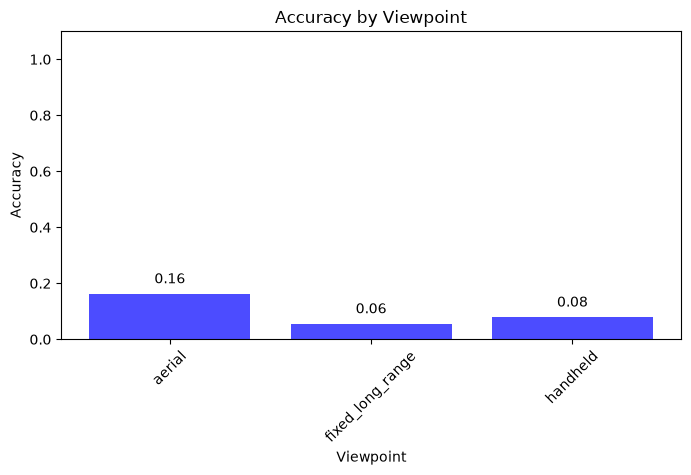

In [48]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='accuracy', title='Accuracy by Viewpoint', ylabel='Accuracy', xlabel='Viewpoint')

### Precision

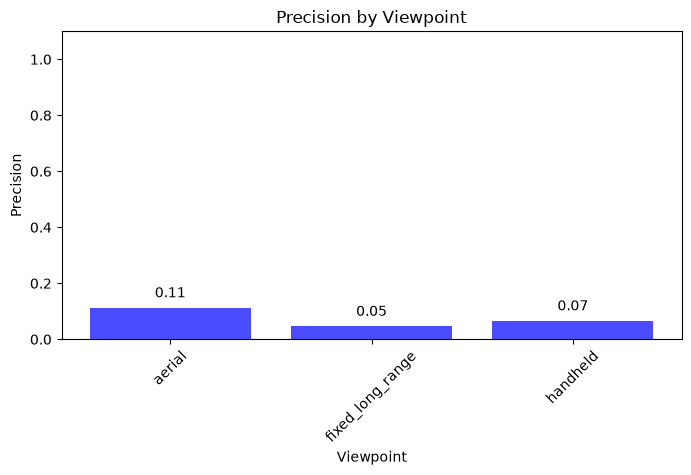

In [49]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='precision', title='Precision by Viewpoint', ylabel='Precision', xlabel='Viewpoint')

### Recall

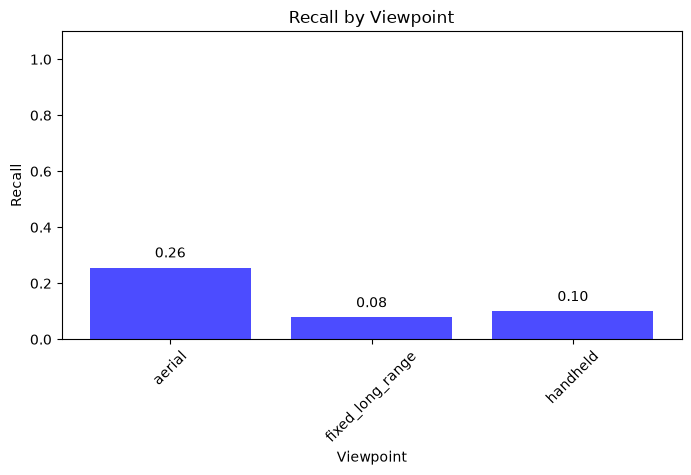

In [50]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='recall', title='Recall by Viewpoint', ylabel='Recall', xlabel='Viewpoint')

### Hit Rate

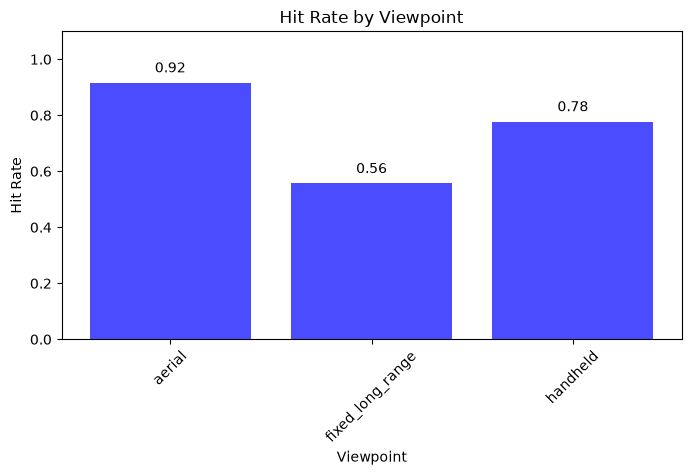

In [51]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='hit_rate', title='Hit Rate by Viewpoint', ylabel='Hit Rate', xlabel='Viewpoint')

### Diversity

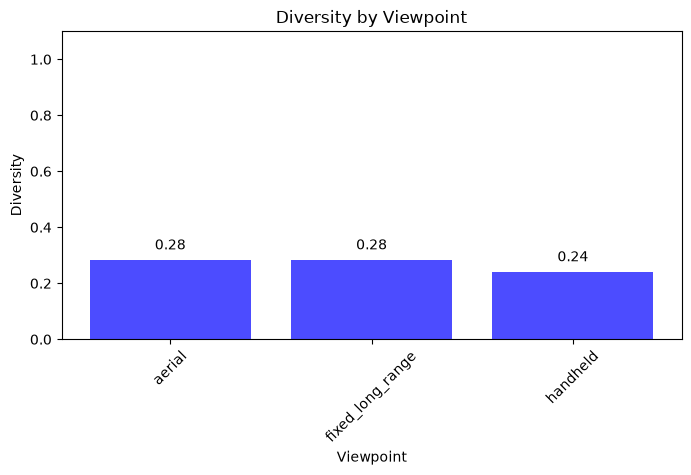

In [52]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='diversity', title='Diversity by Viewpoint', ylabel='Diversity', xlabel='Viewpoint')

### NDCG

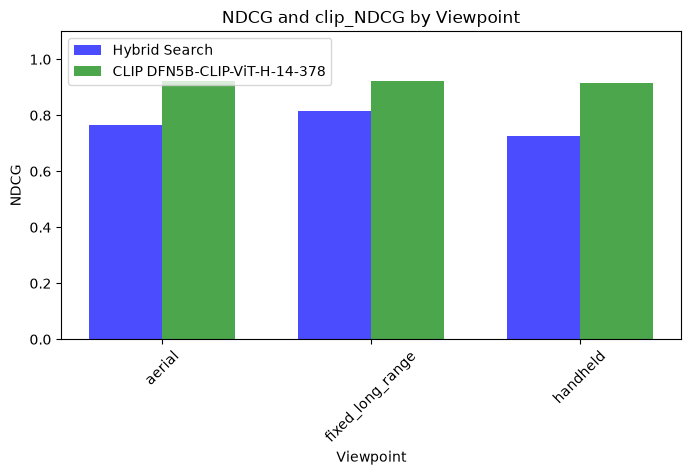

In [53]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='NDCG and clip_NDCG by Viewpoint', xlabel='Viewpoint')

### MRR

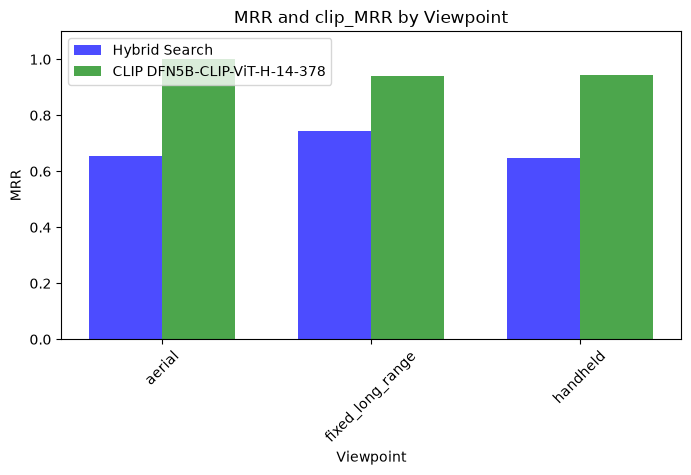

In [54]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='MRR and clip_MRR by Viewpoint', xlabel='Viewpoint', metric="MRR")

## Metrics based on Lighting & Flame Visible

Here we will group by Lighting and Flame Visible and calculate the sum/mean of each metric to see how the system performs under different lighting and flame visible conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [55]:
# Group by Lighting and Flame Visible and calculate the sum/mean of each metric
lighting_flame_visible_metrics = df.groupby(['lighting', 'flame_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
lighting_flame_visible_metrics['flame_visible'] = lighting_flame_visible_metrics['flame_visible'].map({True: 'True', False: 'False'})

#rename columns
lighting_flame_visible_metrics = lighting_flame_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_flame_visible_metrics

,lighting,flame_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,day,False,1875,118,1757,93,1782,0.062933,0.049600,0.090432,0.560000,0.816242,0.924054,0.757111,0.956667,0.284594
1,day,True,100,10,90,6,94,0.100000,0.060000,0.101839,0.750000,0.709062,0.907633,0.833333,1.000000,0.189436
2,dusk,False,175,21,154,18,157,0.120000,0.102857,0.208752,1.000000,0.739537,0.888173,0.528571,0.928571,0.376238
3,dusk,True,25,3,22,1,24,0.120000,0.040000,0.250000,1.000000,0.838269,0.945605,1.000000,1.000000,0.421591
4,ir_nir,False,75,2,73,1,74,0.026667,0.013333,0.008772,0.333333,0.787621,0.901211,0.511111,0.777778,0.146699
5,night,False,225,22,203,21,204,0.097778,0.093333,0.106034,0.777778,0.802366,0.931933,0.637037,0.925926,0.251295
6,night,True,25,2,23,2,23,0.080000,0.080000,0.250000,1.000000,0.515685,0.981848,0.500000,1.000000,0.209567


In [56]:
# Define colors for each supercategory
fl_colors = {
    "True": "red",
    "False": "green",
}

# Assign colors based on supercategory
colors = [fl_colors[sc] for sc in lighting_flame_visible_metrics['flame_visible']]

### Accuracy

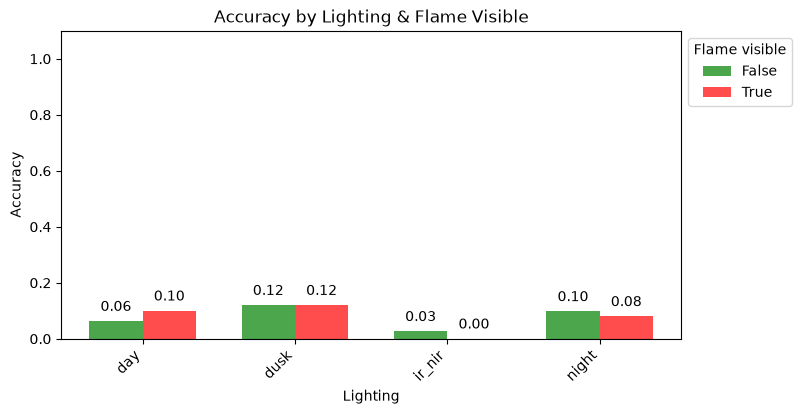

In [57]:
# Accuracy by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='accuracy', 
    color_map=fl_colors, 
    ylabel="Accuracy", 
    xlabel="Lighting", 
    title="Accuracy by Lighting & Flame Visible",
)

### Precision

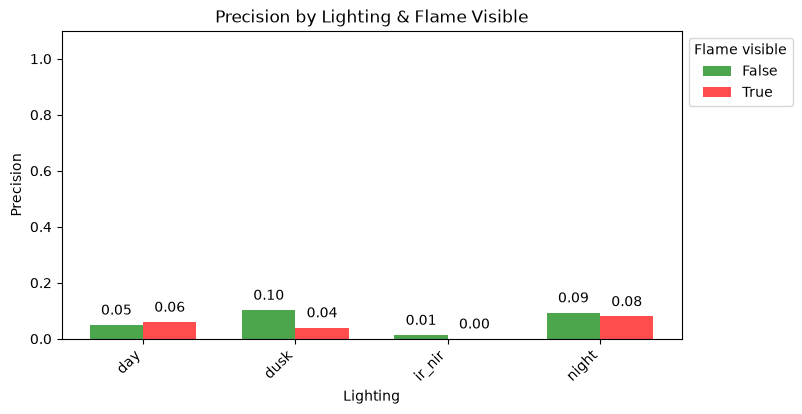

In [58]:
# Precision by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='precision', 
    color_map=fl_colors, 
    ylabel="Precision", 
    xlabel="Lighting", 
    title="Precision by Lighting & Flame Visible",
)

### Recall

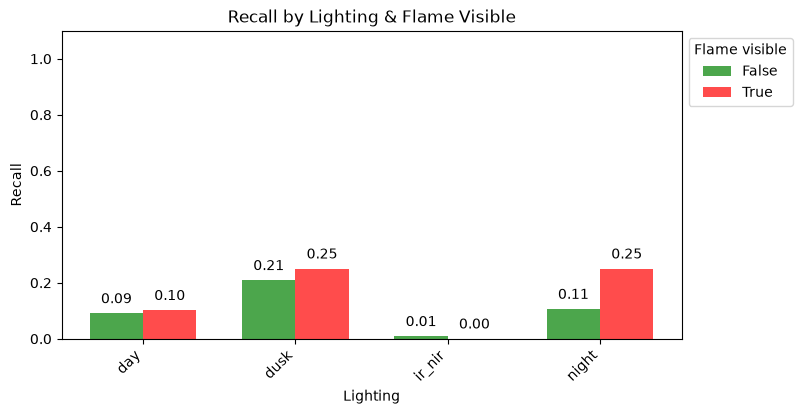

In [59]:
# Recall by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='recall', 
    color_map=fl_colors,
    ylabel="Recall", 
    xlabel="Lighting", 
    title="Recall by Lighting & Flame Visible",
)


### Hit Rate

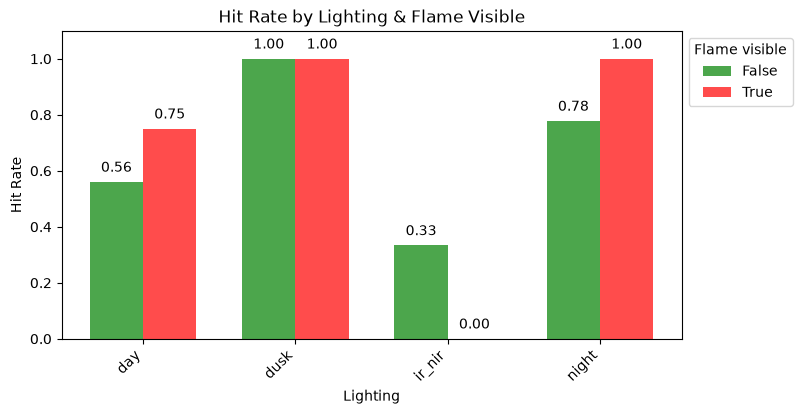

In [60]:
# Recall by Lighting & Flame Visible:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='hit_rate', 
    color_map=fl_colors,
    ylabel="Hit Rate", 
    xlabel="Lighting", 
    title="Hit Rate by Lighting & Flame Visible",
)

### Diversity

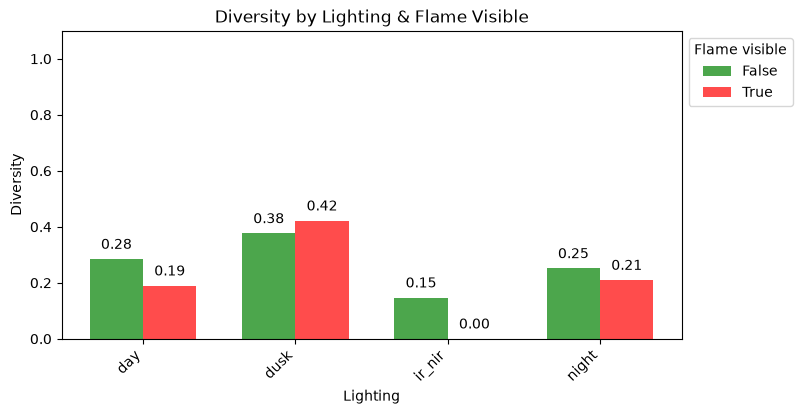

In [61]:
plot_grouped_bar_by_columns(
    lighting_flame_visible_metrics, 
    x_column='lighting', 
    color_column='flame_visible', 
    metric='diversity', 
    color_map=fl_colors,
    ylabel="Diversity", 
    xlabel="Lighting", 
    title="Diversity by Lighting & Flame Visible",
)

### NDCG

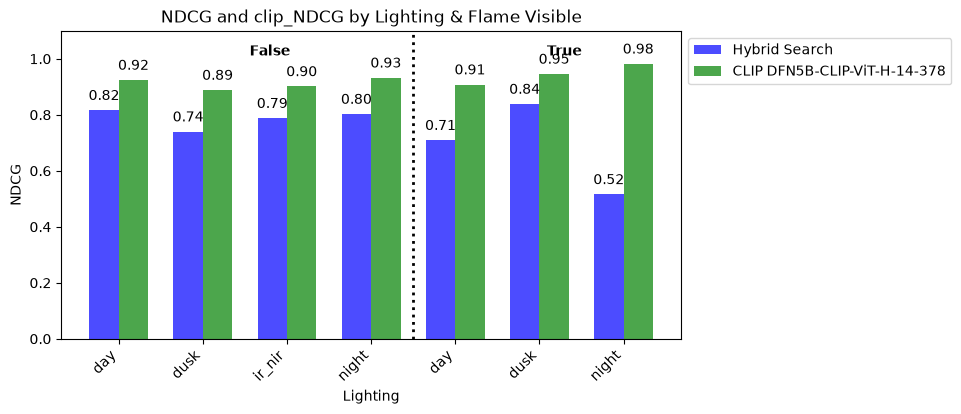

In [62]:
# Sort by flame_visible so group dividers and labels are correct
_ndcg_df = lighting_flame_visible_metrics.sort_values("flame_visible").reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column="lighting",
    group_column="flame_visible",
    title="NDCG and clip_NDCG by Lighting & Flame Visible",
    xlabel="Lighting",
)


### MRR

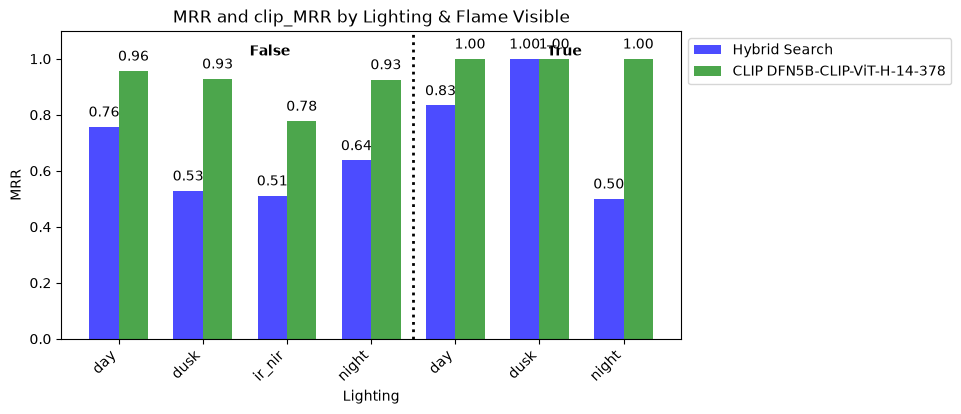

In [63]:
# Sort by flame_visible so group dividers and labels are correct
_mrr_df = lighting_flame_visible_metrics.sort_values("flame_visible").reset_index(drop=True)
plot_multi_rank_comparison(
    _mrr_df,
    x_column="lighting",
    group_column="flame_visible",
    title="MRR and clip_MRR by Lighting & Flame Visible",
    xlabel="Lighting",
    metric="MRR"
)

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v14:**
  * introduced in v13:
    * **Weaviate → Milvus** as the vector database.
    * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
    * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
    * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.
  * v13 additions plus LLM Image Byte Limiting - Caption images are preprocessed before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
* **v15:**
  * **Two-caption prompt** (`scientific_two_captions_v1`): Gemma emits `long_caption`, `short_caption` (≤55 tokens, visible content only), and 15 `keywords`.
  * **CLIP vs BM25 text split**: `caption_vector` embeds **`short_caption` + `keywords`** in one 77-token CLIP pass (keywords used to fall past the truncation cutoff). BM25 `search_text` still indexes **`long_caption` + keywords**.
  * **Schema**: `long_caption` and `short_caption` stored as separate VARCHAR fields (replacing a single `caption` column).
  * Hybrid weights unchanged (`query_alpha=0.4`, `clip_alpha=0.7`). CLIP DFN still reranks on `image_vector`.
* **v16:**
  * **Query-only** (`SKIP_INDEX=true`): reuse the v15 collections. No recaption and no collection drop. The only IR change is hybrid blend weights at query time.
  * **Blend sweep A–H** on `query_alpha` / `clip_alpha`. Production pick **H**: `query_alpha=0.65`, `clip_alpha=0.7` → **46% image / 20% caption / 35% BM25** (v15 was **28 / 12 / 60**).
  * `clip_alpha` did not move hit sets at `query_alpha≤0.6` (A/C vs v15; F vs B). Sage hit collapses between 0.65 and 0.70 — **E fails the v15 Sage floor**.

---

**Overall Metrics Comparison**

v16 is skip-index blend **H** (`query_alpha=0.65`, `clip_alpha=0.7`) on the v15 Firebench collection. **Δ (v16 − v15)** is the blend-only increment. v12 is the Weaviate fused-index reference.

| Metric                   | v12 | v15 | v16 | Δ (v16 − v15) |
| ------------------------ | --- | --- | --- | ------------- |
| **Total Images**         | 2,500 | 2,500 | 2,500 | 0 |
| **Correctly Returned**   | 207 | 154 | 178 | +24 |
| **Incorrectly Returned** | 2,293 | 2,346 | 2,322 | −24 |
| **Relevant Images**      | 152 | 118 | 142 | +24 |
| **Accuracy**             | 0.0828 | 0.0616 | 0.0712 | +0.0096 |
| **Precision**            | 0.0608 | 0.0472 | 0.0568 | +0.0096 |
| **Recall**               | 0.1118 | 0.0816 | 0.1013 | +0.0197 |
| **Hit Rate**             | 0.6300 | 0.5700 | 0.6200 | +0.0500 |
| **Diversity**            | 0.2562 | 0.2883 | 0.2807 | −0.0076 |
| **NDCG**                 | 0.6674 | 0.7930 | 0.8017 | +0.0087 |
| **clip_NDCG**            | 0.8982 | 0.9119 | 0.9217 | +0.0098 |
| **MRR**                  | 0.3659 | 0.7013 | 0.7258 | +0.0245 |
| **clip_MRR**             | 0.8851 | 0.9350 | 0.9492 | +0.0142 |
| **DLQ entries**          | — | 0 | 0 | 0 |

**Alpha sweep (hit / hybrid MRR).** Hit = Success@25. MRR = `rerank_score_reciprocal_rank`. Guardrail: Fire MRR ≥ 0.65.

| Point | Folder | query_alpha | clip_alpha | weights (img / cap / BM25) | Hit | MRR |
| ----- | ------ | ----------- | ---------- | -------------------------- | --- | --- |
| v15 | *(v15 index)* | 0.40 | 0.7 | 28 / 12 / 60 | 57% | 0.701 |
| A | `v16_qa04_ca085` | 0.40 | 0.85 | 34 / 6 / 60 | 57% | 0.696 |
| C | `v16_qa04_ca05` | 0.40 | 0.50 | 20 / 20 / 60 | 57% | 0.701 |
| D | `v16_qa05_ca07` | 0.50 | 0.7 | 35 / 15 / 50 | 57% | 0.701 |
| B | `v16_qa06_ca07` | 0.60 | 0.7 | 42 / 18 / 40 | 62% | 0.726 |
| F | `v16_qa06_ca085` | 0.60 | 0.85 | 51 / 9 / 40 | 62% | 0.726 |
| **H (v16)** | **`v16_qa065_ca07`** | **0.65** | **0.7** | **46 / 20 / 35** | **62%** | **0.726** |
| E | `v16_qa07_ca07` | 0.70 | 0.7 | 49 / 21 / 30 | 69% | 0.765 |

**Why each `v16_qa*` batch was run.** Folder names encode the knobs (`qa` = `query_alpha`, `ca` = `clip_alpha`). Hybrid weights are `WeightedRanker(query_alpha × clip_alpha, query_alpha × (1 − clip_alpha), 1 − query_alpha)` → image / caption / BM25. All seven jobs are **skip-index** on the v15 collections (no recaption). They were launched in three waves so later jobs could condition on earlier ones.

- **Wave 1 — which knob moves anything?**
  - **A / `v16_qa04_ca085`:** hold `query_alpha=0.4` (v15), raise `clip_alpha` 0.7 → 0.85 (more image, less caption). Test whether the dense image/caption split matters while BM25 is still 60%. **This bench:** No-op vs v15 (57% / 0.696). `clip_alpha` dead while BM25 is 60%.
  - **C / `v16_qa04_ca05`:** hold `query_alpha=0.4`, lower `clip_alpha` 0.7 → 0.5 (more caption). Same question, other direction. **This bench:** No-op vs v15 (57% / 0.701). Same lock as A.
  - **B / `v16_qa06_ca07`:** hold `clip_alpha=0.7`, raise `query_alpha` 0.4 → 0.6 (BM25 60% → 40%). Test whether the dense vs BM25 mix is the lever. **This bench:** Unlock: 57% → 62%, MRR 0.70 → 0.73 (guardrail ≥ 0.65 holds).
- **Wave 2 — where is the unlock / cliff, and is `clip_alpha` alive once BM25 drops?**
  - **D / `v16_qa05_ca07`:** `query_alpha=0.5`, `clip_alpha=0.7`. Interpolate v15 and B to find where the BM25 lock breaks. **This bench:** No-op vs v15 (57% / 0.701). Unlock is at 0.60, not 0.50.
  - **E / `v16_qa07_ca07`:** `query_alpha=0.7`, `clip_alpha=0.7`. Push past B: is more dense still worth it, or do Sage/Cloud fall off? **This bench:** 69% / 0.76 — real coverage, rejected because Sage fails at 0.70.
  - **F / `v16_qa06_ca085`:** `query_alpha=0.6`, `clip_alpha=0.85`. Retest `clip_alpha` now that BM25 is 40% and no longer locking. **This bench:** Identical to B (62% / 0.726). `clip_alpha` still dead after unlock.
- **Wave 3 — sit between the unlock and the cliff.**
  - **H / `v16_qa065_ca07`:** `query_alpha=0.65`, `clip_alpha=0.7`. Between B (first unlock, Sage holds) and E (Sage fails). Keep INQUIRE's extra queries without crossing the cliff. Copied to `results/v16/` as the production pick. **This bench:** Identical to B (62% / 0.726). Incipient still ~25% (n=4); blend cannot restore unseen plumes.


---

**Interpretation**

**Isolate v16 vs v15.** Same two-caption ingest, same dual-index, same CLIP DFN rerank, same 12 MiB / 6144-side cap. No recaption. Raising dense weight recovers labeled plume/landscape hits that BM25-heavy v15 left out of k=25. DLQ stays **0**.

**Coverage and ranking both move, H = B.** Hit **57% → 62%** (57/100 → 62/100): **6 gained / 1 lost**. Production **MRR 0.70 → 0.73** (guardrail ≥ 0.65; v12 0.37). Developing **54% → 58%**, mature **56% → 69%**. **Incipient still ~25% (n=4)** — byte limiting still hides one-pixel horizon columns; blend cannot restore pixels Gemma never saw. **E 69% / 0.76** is coverage we do not take (Sage cliff).

---

**Insights**

- **Guardrail holds.** Fire MRR stays well above 0.65 at H (0.73) and at E (0.76). The binding constraint is Sage hit, not Fire ranking.
- **H = B on the hit set.** Unlock is `query_alpha=0.6`. The 0.65 step is free on Firebench relative to B.
- **Incipient is not a blend problem.** 0.25 at v15 and H (E reaches 0.50 on n=4). Next Fire IR work is still **caption resolution for long-range frames**, not more `query_alpha`.
- **A/C/D are no-ops vs v15.** `clip_alpha` does not move this bench in the tested band.
- **Do not read E as the Firebench optimum.** It is real coverage, rejected because Sage fails at 0.70.

---

**Conclusion**

On Firebench, **v16 H is a coverage and ranking win on the v15 index** (hit **57% → 62%**, MRR **0.70 → 0.73**). **H = B.** Incipient stays ~25% (n=4). E's 69% / 0.76 is coverage we do not take. Keep H. Keep the two-caption prompt. Next Fire work is still long-range caption resolution, not rolling back the blend.
